In [40]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


def load_ticker(ticker, start, end):
    return yf.download(
        ticker, 
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )


ex 3.4

In [41]:
ige_ticker = load_ticker('IGE', "2001-11-26", "2007-11-14")


Rp = ige_ticker["Close"].pct_change().dropna()
Rp = np.array(Rp)


Rf = (1+0.04)**(1/252)-1

avgR = Rp.mean()
sd = Rp.std()

Sharpe = np.sqrt(252)*(avgR-Rf)/sd

print(Sharpe)


0.7871675644260606


Dollar-neutral strategy - long IGE, short SPY.

In [163]:
ige = load_ticker('IGE', '2001-11-26', '2007-11-14')
spy = load_ticker('SPY', '2001-11-26', '2007-11-14')

#.squeeze instead of array to switch to time series and keep the date index
ige = ige["Close"].squeeze().pct_change().dropna()
spy = spy["Close"].squeeze().pct_change().dropna()
Rp = (ige - spy)






avgR = Rp.mean()

sd = Rp.std()

Rf = 0.04/252

Sharpe = np.sqrt(252)*(avgR)/sd
print(Sharpe)

0.7692664734677628


Ex 3.5 Maximum drawdown and max drowdown duration

In [226]:
from collections import Counter
cum_Rp = (1+Rp).cumprod()-1


cmax_Rp = cum_Rp.cummax()
drawdown = pd.Series(index=cum_Rp.index, dtype=float)
drawdownduration = pd.Series(index=cum_Rp.index, dtype=float)
for day, value in enumerate(cum_Rp.values):
    drawdown.iloc[day]=(1+value)/(1+cmax_Rp.iloc[day])-1
    if drawdown.iloc[day]==0:
        drawdownduration.iloc[day]=0
    else:
        drawdownduration.iloc[day]=drawdownduration.iloc[day-1]+1
drawdown = drawdown*(-1)

print("Maximum drawdown was:", f"{drawdown.max(): .2%}", "from max value")

longest_drawdown = int(drawdownduration.max())
longest_ddown_end = cmax_Rp.index[np.argmax(drawdownduration)]
longest_ddown_start = cmax_Rp.index[np.argmax(drawdownduration)-int(drawdownduration.max())]
num_end = np.argmax(drawdownduration)
num_start = np.argmax(drawdownduration)- int(drawdownduration.max())


print("Maximum drawdown: ", drawdownduration.max(), "days after a peak return at:", f"{cmax_Rp.iloc[np.argmax(drawdownduration)]:.2%}"
      , f" reached on the day {longest_ddown_start}")


Maximum drawdown was:  18.87% from max value
Maximum drawdown:  499.0 days after a peak return at: 25.90%  reached on the day 2002-07-10 00:00:00


2002-07-10 00:00:00 2004-07-02 00:00:00
2002-07-10 00:00:00 2003-11-21 00:00:00
249


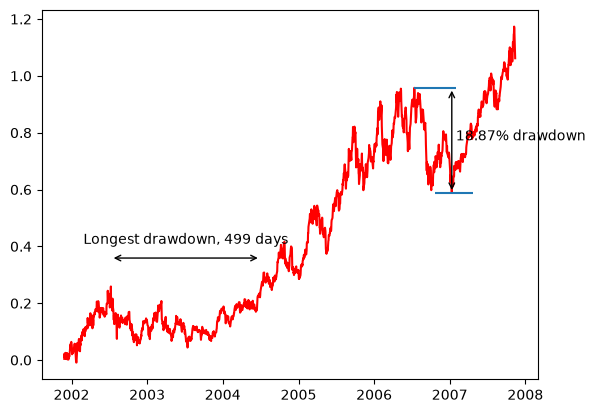

In [254]:
max_drawdown = drawdown.max()
max_drawdown_date = drawdown.index[np.argmax(drawdown)]

peak = cmax_Rp.loc[longest_ddown_start]
mid = longest_ddown_start+(longest_ddown_end-longest_ddown_start)/2




plt.plot(cum_Rp, 'r-')
plt.annotate("", xytext=(longest_ddown_start, peak+0.1), xy=(longest_ddown_end, peak+0.1),
             arrowprops=dict(arrowstyle="<->"))
plt.text(
    mid,
    peak+0.15,
    f"Longest drawdown, {longest_drawdown} days",
    ha="center"
)

plt.annotate("", xytext=(max_drawdown_date, cmax_Rp.loc[max_drawdown_date]), xy =(max_drawdown_date, cum_Rp.loc[max_drawdown_date]),
    arrowprops=dict(arrowstyle="<->"))
plt.text(
    max_drawdown_date,
    (cmax_Rp.loc[max_drawdown_date]+cum_Rp.loc[max_drawdown_date])/2,
    f"{max_drawdown: .2%} drawdown",
    ha="left"
)

backwards = drawdown[:max_drawdown_date][::-1]
peak_date = backwards[backwards==0].index[0]
middle = peak_date+(max_drawdown_date-peak_date)/2

plt.hlines(cum_Rp.loc[max_drawdown_date], peak_date+pd.Timedelta(days=100), max_drawdown_date+pd.Timedelta(days=100))
plt.hlines(cmax_Rp[max_drawdown_date], peak_date, peak_date +pd.Timedelta(days=200))


<Axes: xlabel='Date'>

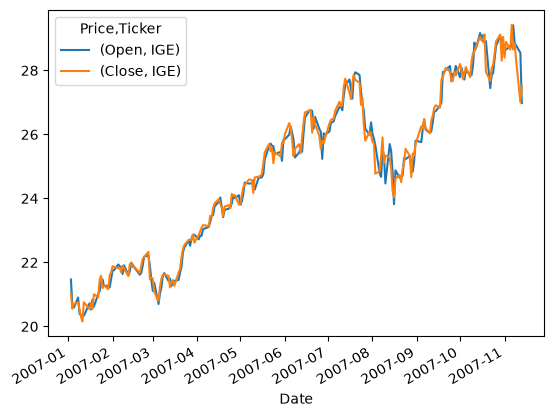

In [20]:
ige_ticker.head()

ige_ticker.loc["2007", ["Open", "Close"]].plot()

Example 3.6
Determine the hedge ratio between GLD and GDX. Backtest the mean-reversion strategy with different exit entry thresholds

In [4]:
def squeeze_fun(ticker):
    return ticker["Close"].squeeze().dropna()

In [ ]:
date1 = '2004-11-18'
date2 = '2006-05-23'
date3= '2007-11-30'
gld = squeeze_fun(load_ticker("GLD", date1, date3))
gdx = squeeze_fun(load_ticker("GDX", date1, date3))



train-test split

In [6]:
intersection = gld.index.intersection(gdx.index)
gld = gld.loc[intersection]
gdx = gdx.loc[intersection]

split_point = int(0.2 * len(intersection))

gld_train = gld.iloc[:split_point]
gld_test = gld.iloc[split_point:]

gdx_train = gdx.iloc[:split_point]
gdx_test = gdx.iloc[split_point:]



finding the hedge ratio

In [7]:
import statsmodels.api as sm

def hedge_ratio(stock, hedge):
    x = hedge 
    y =stock
    x = sm.add_constant(x)
    result = sm.OLS(y,x).fit()
    return result.params[0], result.params[1]



Spread function

In [154]:
def spread_fun(stock1, stock2, hedge):
    spread =  stock1 - hedge*stock2
    return spread


In [156]:
intercept, hedge = hedge_ratio(gld_train.values, gdx_train.values)


h_spread = spread_fun(gld_train.values, gdx_train.values, hedge)

spread = pd.Series(data = spread, index = gld_train.index)


Defining the entry and exit points

In [158]:
h_spread_mean = np.mean(h_spread)
h_spread_sd = np.std(h_spread)





Calculating returns 

signal function

In [200]:
def spread_fun(stock1, stock2, hedge):
    spread =  stock1 - hedge*stock2
    return spread

    

def daily_z_score(stock1, stock2, hedge):
    spread = spread_fun(stock1.values, stock2.values, hedge)
    spread_mean = np.mean(spread)
    spread_std = np.std(spread)

    return (spread[-1]-spread_mean)/spread_std

def rolling_z_scores(stock1, stock2, hedge, start, window):
    z_scores = np.zeros(len(stock1)-start)
    
    for i in range(start, len(stock1)):
        z_scores[i-start]= daily_z_score(stock1.iloc[i-window:i], stock2.iloc[i-window:i], hedge)
    return z_scores





Return function

In [237]:
def strategy_p_and_l(stock1, stock2, hedge, z_scores):
    
    p_and_l = pd.Series(data = np.zeros(len(z_scores)), index = z_scores.index)
    stock2 = stock2 * hedge
    enter_long=None
    enter_short=None
    
    
    for date, z_score in z_scores.items():
        if z_score <= - 2 and enter_long==None:
            enter_long = date
        elif z_score <= -1 and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score >= -1 and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
            enter_long = None
        if z_score >= 2 and enter_short == None:
            enter_short = date
        elif z_score >= 1 and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score <= 1 and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
            enter_short = None    

    return p_and_l
    



<Axes: xlabel='Date'>

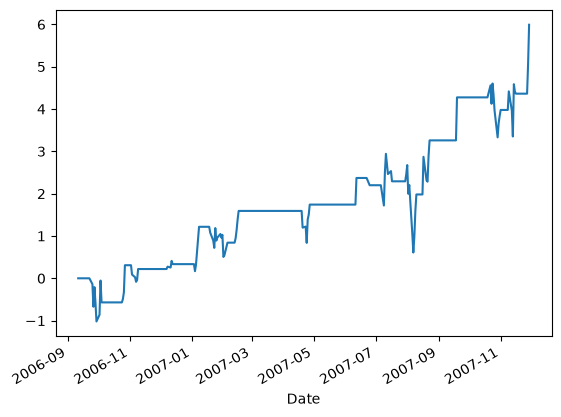

In [238]:
z_scores = rolling_z_scores(gld, gdx, hedge, split_point, 20)

gld_open = load_ticker('GLD', date1, date3)['Open'].squeeze().dropna()
gdx_open = load_ticker('GDX', date1, date3)['Open'].squeeze().dropna()

intersection = gld_open.index.intersection(gdx_open.index)
gld_open = gld_open.loc[intersection]
gdx_open = gdx_open.loc[intersection]

z_scores = pd.Series(data=z_scores, index = gld_open.iloc[-len(z_scores):].index)

p_and_l = strategy_p_and_l(gld_open.loc[z_scores.index], gdx_open.loc[z_scores.index], hedge, z_scores)

p_and_l.cumsum().plot()